【】loglr不能把单侧稀释任务合并看待


In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from itertools import combinations
from IPython.display import display # 用于在Notebook中漂亮地显示表格

warnings.filterwarnings('ignore')

class BehaviorDataAnalyzer:
    def __init__(self, filepath):
        self.filepath = filepath
        self.df = self._load_and_parse_data()
        self.last_used_data = None  # 记录最近一次分析的原始行数据

        
    def _load_and_parse_data(self):
        """Load data and extract features, merge Alm50p7F and Arm50p7F into m50p7F"""
        print(f"Loading data: {self.filepath} ...")
        if self.filepath.endswith('.csv'):
            df = pd.read_csv(self.filepath)
        else:
            df = pd.read_excel(self.filepath)
        
        df['Stage'] = df['Train'].str.extract(r'/(Stage\d+|MPtest)/', expand=False)
        df['Mouse_ID'] = df['Train'].str.extract(r'/([A-Z]\d{2})/', expand=False)

        def extract_treatment(path):
            basename = str(path).split('/')[-1].replace('.pkl', '')
            parts = basename.split('_')
            if len(parts) >= 3:
                treat = parts[1]
                if treat in ['Alm50p9F', 'Arm50p9F']:
                    return 'm50p9F'
                if treat in ['Alm50p7F', 'Arm50p7F']:
                    return 'm50p7F'
                if treat in ['Alm25p9F', 'Arm25p9F']:
                    return 'm25p9F'
                if treat in ['Alm25p7F', 'Arm25p7F']:
                    return 'm25p7F'
                if treat in ['Alm12p9F', 'Arm12p9F']:
                    return 'm12p9F'
                if treat in ['Alm12p7F', 'Arm12p7F']:
                    return 'm12p7F'
                if treat in ['Alm0p9F', 'Arm0p9F']:
                    return 'm0p9F'
                if treat in ['Alm0p7F', 'Arm0p7F']:
                    return 'm0p7F'
                if treat in ['Arc7F', 'Alc7F']:
                    return 'Ac7F'
                
                return treat
            return '00'
            
        df['Treatment'] = df['Train'].apply(extract_treatment)
        df['Date_Parsed'] = pd.to_datetime(df['Date'].astype(str), format='%Y%m%d', errors='coerce')
        
        print("Data loaded! Alm and Arm merged into one group.")
        return df

    def filter_data(self, stage=None, mouse_id=None, start_date=None, end_date=None, treatment=None, label_name="Filtered"):
        """Filter data by conditions"""
        mask = pd.Series([True] * len(self.df))
        
        if stage:
            mask &= self.df['Stage'].isin(stage) if isinstance(stage, list) else self.df['Stage'] == stage
        if mouse_id:
            mask &= self.df['Mouse_ID'].isin(mouse_id) if isinstance(mouse_id, list) else self.df['Mouse_ID'] == mouse_id
        if start_date:
            mask &= self.df['Date_Parsed'] >= pd.to_datetime(start_date)
        if end_date:
            mask &= self.df['Date_Parsed'] <= pd.to_datetime(end_date)
        if treatment:
            mask &= self.df['Treatment'].isin(treatment) if isinstance(treatment, list) else self.df['Treatment'] == treatment
            
        filtered_df = self.df[mask].copy()
        filtered_df['Group_Label'] = label_name
        return filtered_df

    def _print_raw_table(self, data):
        """内部函数：提取并打印原始格式的表格"""
        if data is None or len(data) == 0:
            print("没有数据可显示。")
            return
            

        # 这样打印出来的就是你原始 Excel 里的那些列
        internal_cols = ['Stage_Tag', 'Mouse_ID', 'Treatment_Tag', 'Date_Parsed', 'Group_Label']
        original_format_df = data.drop(columns=[c for c in internal_cols if c in data.columns])
        
        # print("\n" + ">>>" * 10 + " 参与本次分析的原始明细 " + "<<<" * 10)
        # # 如果在 Jupyter/Colab 中，使用 display 会更好看；如果在普通终端，会用 text 打印
        # try:
        #     display(original_format_df)
        # except:
        #     print(original_format_df.to_string())
        # print("-" * 80 + "\n")

    def _get_outliers(self, data):
        """IQR method to detect outliers"""
        if len(data) < 4:
            return pd.Series([], dtype=float)
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        return data[(data < lower_bound) | (data > upper_bound)]

    def compare_and_plot(self, df1, df2, metrics, title="Two Groups Comparison", design="repeated"):
        """Compare two groups with repeated measures design"""
        n_metrics = len(metrics)
        cols = 3
        rows = int(np.ceil(n_metrics / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        axes = np.array(axes).flatten()
        
        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            
            valid_df1 = df1[df1[metric].notna() & (df1[metric] != 0)].copy()
            valid_df2 = df2[df2[metric].notna() & (df2[metric] != 0)].copy()
            
            # Use all raw data points for plotting
            valid_combined = pd.concat([valid_df1, valid_df2], ignore_index=True)
            
            p_val = 1.0
            test_name = "N/A"
            
            if design == "repeated":
                # Pairing requires aligning by Mouse_ID
                agg1 = valid_df1.groupby('Mouse_ID')[metric].mean()
                agg2 = valid_df2.groupby('Mouse_ID')[metric].mean()
                common_mice = agg1.index.intersection(agg2.index)
                
                if len(common_mice) >= 3:
                    data1_stat = agg1[common_mice].values
                    data2_stat = agg2[common_mice].values
                    
                    diff = data1_stat - data2_stat
                    _, p_norm = stats.shapiro(diff)
                    
                    if p_norm > 0.05:
                        stat, p_val = stats.ttest_rel(data1_stat, data2_stat)
                        test_name = "Paired t"
                    else:
                        stat, p_val = stats.wilcoxon(data1_stat, data2_stat)
                        test_name = "Wilcoxon"
                        print(f"Data for {metric} 不是正态分布. Using Wilcoxon test instead of paired t-test.")
                else:
                    test_name = "Independent (Fallback)"
                    design = "independent"
            
            if design == "independent":
                data1_stat = valid_df1[metric].values
                data2_stat = valid_df2[metric].values
                if len(data1_stat) >=3 and len(data2_stat) >= 3:
                    _, p_n1 = stats.shapiro(data1_stat)
                    _, p_n2 = stats.shapiro(data2_stat)
                    if p_n1 > 0.05 and p_n2 > 0.05:
                        _, p_var = stats.levene(data1_stat, data2_stat)
                        stat, p_val = stats.ttest_ind(data1_stat, data2_stat, equal_var=(p_var > 0.05))
                        test_name = "t-test"
                    else:
                        stat, p_val = stats.mannwhitneyu(data1_stat, data2_stat)
                        test_name = "M-W U"

            if p_val < 0.001: star = '***'
            elif p_val < 0.01: star = '**'
            elif p_val < 0.05: star = '*'
            else: star = 'ns'
            
            # Plot raw data points
            sns.barplot(data=valid_combined, x='Group_Label', y=metric, ax=ax, capsize=.1, errorbar='se', palette='Set2')
            sns.stripplot(data=valid_combined, x='Group_Label', y=metric, ax=ax, color='black', alpha=0.5, jitter=True, size=5)
            
            y_max = valid_combined[metric].max()
            y_offset = y_max * 0.05
            if not np.isnan(y_max):
                ax.plot([0, 0, 1, 1], [y_max + y_offset, y_max + y_offset*2, y_max + y_offset*2, y_max + y_offset], lw=1.5, c='k')
                ax.text(0.5, y_max + y_offset*2, star, ha='center', va='bottom', color='k', fontsize=14)
            
            ax.set_title(f"{metric}\n{test_name} p={p_val:.4f}\n(Raw data)")
            ax.set_xlabel("")
            ax.set_ylabel("Value")

        for i in range(idx + 1, len(axes)):
            fig.delaxes(axes[i])
            
        plt.tight_layout()
        plt.suptitle(title, y=1.02, fontsize=16, fontweight='bold')
        plt.show()
    def compare_multiple_groups(self, group_dict, metrics, design="repeated", 
                                title="Multiple Groups Comparison", show_ns=True): # 1. 增加 show_ns 开关
        """Compare multiple groups with repeated measures design"""
        from itertools import combinations
        import scipy.stats as stats
        import numpy as np
        import pandas as pd
        import seaborn as sns
        import matplotlib.pyplot as plt

        groups = list(group_dict.keys())
        n_metrics = len(metrics)
        cols = 3
        rows = int(np.ceil(n_metrics / cols))
        fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        axes = np.array(axes).flatten()

        for idx, metric in enumerate(metrics):
            ax = axes[idx]
            valid_groups = {}
            for g in groups:
                df = group_dict[g]
                valid_df = df[df[metric].notna() & (df[metric] != 0)].copy()
                if len(valid_df) > 0:
                    valid_groups[g] = valid_df

            valid_keys = list(valid_groups.keys())
            if len(valid_keys) < 2:
                ax.set_title(f"{metric}\nInsufficient Data")
                continue

            test_name = ""
            p_overall = 1.0
            design_used = design
            stat_data_dict = {}

            # 数据配对逻辑 (Repeated Measures)
            if design == "repeated":
                common_mice = None
                for g in valid_keys:
                    mice = set(valid_groups[g]['Mouse_ID'].dropna().unique())
                    common_mice = mice if common_mice is None else common_mice.intersection(mice)
                
                if common_mice and len(common_mice) >= 3:
                    for g in valid_keys:
                        agg = valid_groups[g].groupby('Mouse_ID')[metric].mean()
                        stat_data_dict[g] = agg[list(common_mice)].values
                else:
                    design_used = "independent"

            if design_used == "independent":
                for g in valid_keys:
                    stat_data_dict[g] = valid_groups[g][metric].values

            # 整体检验
            if len(valid_keys) >= 3:
                if design_used == "repeated":
                    stat, p_overall = stats.friedmanchisquare(*[stat_data_dict[g] for g in valid_keys])
                    test_name = "Friedman"
                else:
                    stat, p_overall = stats.kruskal(*[stat_data_dict[g] for g in valid_keys])
                    test_name = "Kruskal-Wallis"

            # 两两比较
            post_hoc_results = []
            if p_overall < 0.05 or len(valid_keys) == 2:
                pairs = list(combinations(valid_keys, 2))
                n_comparisons = len(pairs) if len(valid_keys) > 2 else 1
                for g1, g2 in pairs:
                    d1, d2 = stat_data_dict[g1], stat_data_dict[g2]
                    if len(d1) < 3 or len(d2) < 3: continue
                    
                    if design_used == "repeated":
                        diff = d1 - d2
                        _, p_norm = stats.shapiro(diff)
                        p_ph = stats.ttest_rel(d1, d2)[1] if p_norm > 0.05 else stats.wilcoxon(d1, d2)[1]
                    else:
                        p_ph = stats.mannwhitneyu(d1, d2)[1]
                    
                    p_corrected = min(p_ph * n_comparisons, 1.0)
                    if p_corrected < 0.001: star = '***'
                    elif p_corrected < 0.01: star = '**'
                    elif p_corrected < 0.05: star = '*'
                    else: star = 'ns'
                    
                    post_hoc_results.append({'pair': f"{g1} vs {g2}", 'p_raw': p_ph, 'p_corr': p_corrected, 'star': star})

            # 绘图
            plot_df = pd.concat([valid_groups[g].assign(Group_Label=g) for g in valid_keys])
            sns.barplot(data=plot_df, x='Group_Label', y=metric, ax=ax, capsize=.1, errorbar='se', palette='Set2')
            sns.stripplot(data=plot_df, x='Group_Label', y=metric, ax=ax, color='black', alpha=0.5, jitter=True, size=5)
            
            y_max = plot_df[metric].max()
            y_offset = y_max * 0.08
            # 显示整体 p 值 (如果不是显著且 show_ns=False，则可选择不显示，这里保留整体 p 值标注)
            if len(valid_keys) >= 3:
                p_text = "p<0.0001" if p_overall < 0.0001 else f"p={p_overall:.4f}"
                ax.text(len(valid_keys)/2 - 0.5, y_max + y_offset*3, f"{test_name}\n{p_text}", ha='center', va='bottom', fontsize=8)

            # 显示事后两两比较结果 (核心逻辑修改点)
            if post_hoc_results:
                y_pos = 0.95 
                for r in post_hoc_results:
                    is_significant = r['star'] != 'ns'
                    
                    # 2. 如果不显示 ns 且 结果不显著，则跳过此次循环
                    if not show_ns and not is_significant:
                        continue
                    
                    p_str = "p<0.001" if r['p_corr'] < 0.001 else f"p={r['p_corr']:.3f}"
                    text_str = f"{r['pair']}: {r['star']} ({p_str})"
                    text_color = 'darkred' if is_significant else 'black'
                    
                    ax.text(0.02, y_pos, text_str, ha='left', va='top', 
                            fontsize=7, color=text_color, transform=ax.transAxes)
                    y_pos -= 0.04 

            ax.set_title(f"{metric}")
            ax.set_xlabel("")
            ax.set_ylabel("")

        for i in range(idx + 1, len(axes)): fig.delaxes(axes[i])
        plt.tight_layout()
        plt.suptitle(title, y=1.02, fontsize=14, fontweight='bold')
        plt.show()
    
    def print_training_pipeline(self, mouse_id=None):
        """
        打印每只老鼠的训练流水线（Pipeline）。
        总结逻辑：按时间顺序，将连续重复的任务合并，并统计连续进行的次数。
        """
        from itertools import groupby
        
        # 1. 准备数据：按日期排序
        pipeline_df = self.df.dropna(subset=['Date_Parsed', 'Mouse_ID', 'Treatment', 'Stage']).copy()
        pipeline_df = pipeline_df.sort_values(['Mouse_ID', 'Date_Parsed'])
        
        # 如果指定了某只鼠，则只看那一只；否则看全部
        target_mice = [mouse_id] if mouse_id else pipeline_df['Mouse_ID'].unique()
        
        print("\n" + "="*20 + " MOUSE TRAINING PIPELINE SUMMARY " + "="*20)
        
        for mouse in target_mice:
            mouse_data = pipeline_df[pipeline_df['Mouse_ID'] == mouse]
            if mouse_data.empty:
                print(f"\n[Mouse {mouse}]: 无训练记录")
                continue
            
            # 提取任务序列（Treatment 和 Stage 的组合）
            # 我们关注的是 Treatment 的连续变化
            task_sequence = mouse_data['Treatment'].tolist()
            stage_sequence = mouse_data['Stage'].tolist()
            dates = mouse_data['Date_Parsed'].dt.strftime('%Y-%m-%d').tolist()
            
            # 合并连续相同的任务
            # 这里的 logic 是：将 (Treatment, Stage) 相同的连续天数归为一类
            combined_tasks = []
            current_idx = 0
            for task, group in groupby(zip(task_sequence, stage_sequence)):
                group_list = list(group)
                count = len(group_list)
                start_date = dates[current_idx]
                end_date = dates[current_idx + count - 1]
                
                combined_tasks.append({
                    'task': task[0],
                    'stage': task[1],
                    'count': count,
                    'start': start_date,
                    'end': end_date
                })
                current_idx += count

            # 2. 打印输出
            print(f"\n▶▶▶ Mouse ID: {mouse}")
            print("-" * 60)
            for i, step in enumerate(combined_tasks, 1):
                arrow = "  └─→ " if i > 1 else "  [START] "
                print(f"{arrow}Step {i}: {step['stage']} | {step['task']}")
                print(f"      持续时长: {step['count']} 天 ({step['start']} 至 {step['end']})")
        
        print("\n" + "="*70)

    def print_training_pipeline2(self, mouse_id=None):
        """
        打印每只老鼠的训练流水线（Pipeline）。
        总结逻辑：按时间顺序，将连续重复的任务合并，并统计连续进行的次数。
        输出横向表格。
        """
        from itertools import groupby
        
        # 1. 准备数据：按日期排序
        pipeline_df = self.df.dropna(subset=['Date_Parsed', 'Mouse_ID', 'Treatment', 'Stage']).copy()
        pipeline_df = pipeline_df.sort_values(['Mouse_ID', 'Date_Parsed'])
        
        # 如果指定了某只鼠，则只看那一只；否则看全部
        target_mice = [mouse_id] if mouse_id else pipeline_df['Mouse_ID'].unique()
        
        # 收集每只鼠的任务段
        mouse_pipeline = {}
        max_steps = 0
        
        for mouse in target_mice:
            mouse_data = pipeline_df[pipeline_df['Mouse_ID'] == mouse]
            if mouse_data.empty:
                continue
            
            task_sequence = mouse_data['Treatment'].tolist()
            stage_sequence = mouse_data['Stage'].tolist()
            
            # 合并连续相同的任务
            combined_tasks = []
            for task, group in groupby(zip(task_sequence, stage_sequence)):
                group_list = list(group)
                count = len(group_list)
                combined_tasks.append({
                    'task': task[0],
                    'stage': task[1],
                    'count': count
                })
            
            mouse_pipeline[mouse] = combined_tasks
            max_steps = max(max_steps, len(combined_tasks))
        
        # 2. 构建横向表格
        if mouse_pipeline:
            # 构建表头
            columns = ['Mouse_ID']
            for i in range(max_steps):
                columns.append(f'Task_{i+1}')
            
            # 构建数据行
            rows = []
            for mouse in target_mice:
                if mouse not in mouse_pipeline:
                    continue
                pipeline_steps = mouse_pipeline[mouse]
                row = {'Mouse_ID': mouse}
                for i, step in enumerate(pipeline_steps):
                    # 格式：Treatment(天数d)
                    row[f'Task_{i+1}'] = f"{step['task']}({step['count']}d)"
                rows.append(row)
            
            result_df = pd.DataFrame(rows, columns=columns)
        with pd.option_context('display.max_columns', None, 'display.max_rows', None):
            display(result_df)

        print("\n" + "="*70)

    def print_pipeline_table(self):
        """
        以紧凑的表格形式输出每只老鼠的 Pipeline。
        格式示例: A07 P9Fx3 T9Fx6 (间隔 12 个月) T9Fx4 ...
        """
        from itertools import groupby
        import pandas as pd

        # 1. 准备数据：按日期排序
        pipeline_df = self.df.dropna(subset=['Date_Parsed', 'Mouse_ID', 'Treatment', 'Stage']).copy()
        pipeline_df = pipeline_df.sort_values(['Mouse_ID', 'Date_Parsed'])
        
        target_mice = pipeline_df['Mouse_ID'].unique()
        
        print("\n" + "="*20 + " COMPACT TRAINING PIPELINE TABLE " + "="*20)
        
        for mouse in target_mice:
            mouse_data = pipeline_df[pipeline_df['Mouse_ID'] == mouse]
            
            task_sequence = mouse_data['Treatment'].tolist()
            stage_sequence = mouse_data['Stage'].tolist()
            # 这里保留 datetime 对象以便计算差值
            dates_dt = mouse_data['Date_Parsed'].tolist()
            
            combined_tasks = []
            current_idx = 0
            # 这里的 logic 保持一致：合并 Treatment 和 Stage 相同的连续天数
            for task, group in groupby(zip(task_sequence, stage_sequence)):
                group_list = list(group)
                count = len(group_list)
                start_date = dates_dt[current_idx]
                end_date = dates_dt[current_idx + count - 1]
                
                combined_tasks.append({
                    'task': task[0],
                    'count': count,
                    'start': start_date,
                    'end': end_date
                })
                current_idx += count

            # 2. 构建单行输出字符串
            output_str = f"{mouse} "
            
            for i in range(len(combined_tasks)):
                step = combined_tasks[i]
                
                # 添加当前任务块描述，例如 P9Fx3
                output_str += f"{step['task']}x{step['count']} "
                
                # 如果不是最后一个任务块，计算与下一个块的间隔
                if i < len(combined_tasks) - 1:
                    next_step = combined_tasks[i+1]
                    # 计算当前块结束与下一个块开始之间的天数差
                    diff_days = (next_step['start'] - step['end']).days
                    
                    # 如果间隔大于 30 天，计算大约多少个月
                    if diff_days > 30:
                        months = diff_days // 30
                        output_str += f"(间隔 {months} 个月) "
            
            print(output_str)
            
        print("="*70 + "\n")


    def plot_training_log(self):
        """
        可视化所有老鼠的整体训练记录日志（复刻 R 语言高对比度时间线图）
        """
        import matplotlib.dates as mdates
        import pandas as pd
        import matplotlib.pyplot as plt
        import seaborn as sns
        
        # 1. 提取需要用到的非空数据
        # 修复：去除了_Tag后缀，以匹配你环境中的真实列名
        plot_df = self.df.dropna(subset=['Date_Parsed', 'Mouse_ID']).copy()
        
        if plot_df.empty:
            print("没有足够的日期和老鼠数据用于绘图。")
            return
            
        # 2. 按组排序 (Sorted by Group)
        # 计算每只老鼠归属最多的组别，据此将老鼠排序，让同组的鼠在 Y 轴靠拢
        mouse_group = plot_df.groupby('Mouse_ID')['Treatment'].agg(lambda x: x.value_counts().index[0])
        # 先按组别排序，再按老鼠ID排序
        mouse_group = mouse_group.reset_index().sort_values(by=['Treatment', 'Mouse_ID'], ascending=[True, False])
        sorted_mice = mouse_group['Mouse_ID'].tolist()
        
        # 将 Mouse_ID 转为有顺分类变量，锁定 Y 轴排列顺序
        plot_df['Mouse_ID'] = pd.Categorical(plot_df['Mouse_ID'], categories=sorted_mice, ordered=True)
        
        # 3. 自定义高对比度色板与形状映射
        my_palette = [
            "#E41A1C", "#11F709", "#D006EF", "#00441B", "#7F0000",
            "#4575B4", "#FEC44F", "#525252", "#6203B5", "#FF7F00",
            "#002366", "#FFFF33", "#F781BF", "#F55C03", "#7EBCA8",
            "#EADFE5", "#029D6E", "#866CDB", "#050505"
        ]
        
        # 动态分配颜色
        unique_groups = sorted(plot_df['Treatment'].unique())
        color_map = {grp: my_palette[i % len(my_palette)] for i, grp in enumerate(unique_groups)}
        
        # 指定形状 (matplotlib标记)
        shape_map = {
            "MPtest": "o",  # 实心圆
            "Stage3": "s",  # 实心方块
            "Stage4": "^",  # 实心三角
            "Unknown": "X"  # 叉号 
        }
        # 兜底逻辑：防止出现没定义形状的Stage导致报错
        for stg in plot_df['Stage'].unique():
            if stg not in shape_map:
                shape_map[stg] = "D" # 默认使用实心菱形
                
        # 4. 开始绘图
        fig, ax = plt.subplots(figsize=(14, max(6, len(sorted_mice) * 0.4)))
        
        # 绘制背景灰色横线 (等效于 geom_hline)
        for mouse in sorted_mice:
            ax.axhline(y=mouse, color="#F2F2F2", linewidth=2.5, zorder=1)
            
        # 绘制散点图 (等效于 geom_point)
        sns.scatterplot(
            data=plot_df, 
            x='Date_Parsed', 
            y='Mouse_ID', 
            hue='Treatment', 
            style='Stage',
            palette=color_map,
            markers=shape_map,
            s=125,          # 点的大小 
            alpha=0.9, 
            ax=ax,
            zorder=2
        )
        
        # 5. 坐标轴与主题设置
        ax.set_title("Mouse Training Progress Log (Sorted by Group)", fontsize=16, fontweight='bold', pad=20)
        ax.set_xlabel("Date", fontsize=12, fontweight='bold')
        ax.set_ylabel("Mouse ID", fontsize=12, fontweight='bold')
        
        # X 轴时间格式化：2 weeks interval
        ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%d'))
        plt.setp(ax.get_xticklabels(), rotation=45, ha='right', rotation_mode="anchor")
        
        # 极简主题调整
        sns.despine(left=True, bottom=False)
        ax.yaxis.set_ticks_position('none') # 去除 Y 轴小刻度线
        ax.grid(axis='x', color='gray', linestyle=':', alpha=0.3) 
        
        # 6. 图例设置 (将图例移到底部并分列)
        handles, labels = ax.get_legend_handles_labels()
        if handles:
            ax.legend(
                handles, labels, 
                loc='upper center', 
                bbox_to_anchor=(0.5, -0.15), 
                ncol=6,  
                frameon=False, 
                title_fontsize=11,
                prop={'weight':'bold'}
            )
        
        plt.tight_layout()
        plt.show()

    def filter_pipeline_sequence(self, sequence, metrics, strict=False):
        """
        修正版：识别并提取符合特定Pipeline序列的老鼠数据。
        优先匹配最长路径，避免重复抓取。
        """
        from itertools import groupby
        import pandas as pd
        
        # 1. 预处理
        df_sorted = self.df.dropna(subset=['Date_Parsed', 'Mouse_ID', 'Treatment']).sort_values(['Mouse_ID', 'Date_Parsed'])
        
        sequence_labels = [f"{i+1}_{task}" for i, task in enumerate(sequence)]
        matched_groups_by_pos = {label: [] for label in sequence_labels}
        found_any_mouse = False

        # 2. 遍历每只鼠
        for mouse, mouse_data in df_sorted.groupby('Mouse_ID'):
            task_segments = []
            for task, group in groupby(range(len(mouse_data)), key=lambda i: mouse_data.iloc[i]['Treatment']):
                task_segments.append((task, list(group))) 
            
            seq_len = len(sequence)
            
            i = 0
            while i < len(task_segments):
                match_found_for_this_i = False
                # ★ 核心改进：从最长可能的匹配开始尝试 (由长到短)
                current_max_match = seq_len if strict else min(len(task_segments) - i, seq_len)
                
                for match_len in range(current_max_match, 0, -1): # 从长到短
                    current_window_tasks = [task_segments[i + j][0] for j in range(match_len)]
                    target_seq = sequence[:match_len]
                    
                    if current_window_tasks == target_seq:
                        # 只有当满足 strict 要求，或者不要求 strict 时才记录
                        if strict and match_len < seq_len:
                            continue
                            
                        found_any_mouse = True
                        match_found_for_this_i = True
                        for j in range(match_len):
                            target_label = sequence_labels[j]
                            indices = task_segments[i + j][1]
                            segment_data = mouse_data.iloc[indices].copy()
                            segment_data['Group_Label'] = target_label
                            matched_groups_by_pos[target_label].append(segment_data)
                        
                        # 匹配成功后，跳过这一整段已匹配的任务，防止重复计数
                        i += match_len 
                        break
                
                if not match_found_for_this_i:
                    i += 1

        if not found_any_mouse:
            print(f"未找到符合序列 {' -> '.join(sequence)} 的老鼠。")
            return

        # 3. 汇总数据 (过滤掉没有数据的 Label)
        final_group_dict = {}
        all_segments_list = []
        for label in sequence_labels:
            if matched_groups_by_pos[label]:
                combined_df = pd.concat(matched_groups_by_pos[label], ignore_index=True)
                final_group_dict[label] = combined_df
                all_segments_list.append(combined_df)

        if not all_segments_list:
            print("匹配到了序列，但提取出的有效数据行为空。")
            return

        self.last_used_data = pd.concat(all_segments_list, ignore_index=True)
        
        print(f"\n匹配成功！序列为: {' -> '.join(sequence)}")
        self._print_raw_table(self.last_used_data)

        # 4. 调用多组比较
        # 只有当匹配到的组数 > 1 时才进行多组比较
        if len(final_group_dict) > 1:
            self.compare_multiple_groups(
                group_dict=final_group_dict, 
                metrics=target_metrics, 
                design="repeated", 
                title=f"Sequence: {' -> '.join(sequence)}"
            )
        else:
            print("匹配到的阶段不足 2 个，无法进行多组比较。")


    def split_and_compare_by_date(self, df, metrics, title="Early vs Late"):
        """
        按每只鼠独立时间轴对半拆分。
        逻辑：
        1. 遍历每只鼠，找到它在该数据集下的所有天数。
        2. 对半切开。
        3. 汇总后绘图，并打印原始数据表。
        """
        list_first, list_second = [], []
        mice = df['Mouse_ID'].dropna().unique()
        
        for mouse in mice:
            m_df = df[df['Mouse_ID'] == mouse].copy()
            u_dates = m_df['Date_Parsed'].dropna().sort_values().unique()
            if len(u_dates) < 2:
                continue
            
            mid = (len(u_dates) + 1) // 2
            list_first.append(m_df[m_df['Date_Parsed'].isin(u_dates[:mid])])
            list_second.append(m_df[m_df['Date_Parsed'].isin(u_dates[mid:])])
            
        if not list_first:
            print("数据不足，无法拆分。")
            return

        df_f = pd.concat(list_first, ignore_index=True)
        df_s = pd.concat(list_second, ignore_index=True)
        df_f['Group_Label'], df_s['Group_Label'] = "Early", "Late"
        
        # 记录并打印原始数据
        self.last_used_data = pd.concat([df_f, df_s], ignore_index=True)
        self._print_raw_table(self.last_used_data)
        
        # 调用绘图函数（假设你已经保留了之前的 compare_and_plot）
        self.compare_and_plot(df_f, df_s, metrics, title)

    

    def analyze_regression_pipeline(
        self,
        df,
        x_col,
        metrics,
        design="independent",
        title_suffix="",
        transformation=None,
        remove_outliers=True,
        outlier_method="both",   # studentized / cooks / both
        robust=True,
        save_outliers=True):
        
              
        """
        全自动化回归分析流水线：
        1. 自动遍历多个 metrics
        2. 回归统计 + 残差正态性检验 + 方差齐性检验
        3. 绘制趋势图、Q-Q图、残差 vs 拟合值图
        4. 支持 'independent' 或 'repeated' 实验设计
        """
        import statsmodels.api as sm
        import scipy.stats as stats
        from statsmodels.stats.diagnostic import het_breuschpagan
        import matplotlib.pyplot as plt
        import seaborn as sns
        import pandas as pd

        results_summary = []

        for y_metric in metrics:
            p_data = df.dropna(subset=[x_col, y_metric]).copy()
            # 离群点去除（IQR方法）
            if remove_outliers:
                Q1 = p_data[y_metric].quantile(0.25)
                Q3 = p_data[y_metric].quantile(0.75)
                IQR = Q3 - Q1

                lower_bound = Q1 - 1.5 * IQR
                upper_bound = Q3 + 1.5 * IQR

                original_n = len(p_data)

                p_data = p_data[
                    (p_data[y_metric] >= lower_bound) &
                    (p_data[y_metric] <= upper_bound)
                ].copy()

                removed_n = original_n - len(p_data)

                print(f"[{y_metric}] Removed {removed_n} outliers")
            if len(p_data) <= 3:
                print(f"指标 [{y_metric}] 有效数据点不足(至少需4个)，跳过回归。")
                continue

            # =====================================================
            # 线性回归计算
            # =====================================================

            X = sm.add_constant(p_data[x_col])

            # 假设 transformation 变量指定类型
            if transformation == "logit":
                eps = 1e-6
                y = np.log(
                    (p_data[y_metric].clip(eps, 1-eps)) /
                    (1 - p_data[y_metric].clip(eps, 1-eps))
                )

            elif transformation == "log":
                y = np.log(p_data[y_metric] + 1)

            elif transformation == "sqrt":
                y = np.sqrt(p_data[y_metric])

            elif transformation == "square":
                y = np.power(p_data[y_metric], 2)

            else:
                y = p_data[y_metric]


            # =====================================================
            # 初始OLS拟合
            # =====================================================

            initial_model = sm.OLS(y, X).fit()

            influence = initial_model.get_influence()

            # studentized residual
            student_resid = influence.resid_studentized_external

            # Cook distance
            cooks_d = influence.cooks_distance[0]

            # 阈值
            n = len(p_data)
            p = X.shape[1]

            student_threshold = 3
            cook_threshold = 4 / n

            # =====================================================
            # 标记异常点
            # =====================================================

            p_data["is_outlier"] = False

            if remove_outliers:

                if outlier_method == "studentized":

                    outlier_mask = np.abs(student_resid) > student_threshold

                elif outlier_method == "cooks":

                    outlier_mask = cooks_d > cook_threshold

                else:  # both

                    outlier_mask = (
                        (np.abs(student_resid) > student_threshold) |
                        (cooks_d > cook_threshold)
                    )

                p_data.loc[:, "is_outlier"] = outlier_mask

                outliers_df = p_data[p_data["is_outlier"]].copy()

                # 保存异常点
                if save_outliers and len(outliers_df) > 0:

                    outliers_df["studentized_residual"] = student_resid[outlier_mask]
                    outliers_df["cooks_distance"] = cooks_d[outlier_mask]

                    outlier_file = f"outliers_{y_metric}.csv"

                    outliers_df.to_csv(outlier_file, index=False)

                    print(f"[{y_metric}] Outliers saved -> {outlier_file}")

                # 删除异常点
                p_data = p_data[~p_data["is_outlier"]].copy()

                print(f"[{y_metric}] Removed {np.sum(outlier_mask)} outliers")


            # =====================================================
            # 重新构建X/y
            # =====================================================

            X = sm.add_constant(p_data[x_col])

            if transformation == "logit":
                eps = 1e-6
                y = np.log(
                    (p_data[y_metric].clip(eps, 1-eps)) /
                    (1 - p_data[y_metric].clip(eps, 1-eps))
                )

            elif transformation == "log":
                y = np.log(p_data[y_metric] + 1)

            elif transformation == "sqrt":
                y = np.sqrt(p_data[y_metric])

            elif transformation == "square":
                y = np.power(p_data[y_metric], 2)

            else:
                y = p_data[y_metric]


            # =====================================================
            # Robust Regression

            ols_model = sm.OLS(y, X).fit()

            if robust:

                model = sm.RLM(
                    y,
                    X,
                    M=sm.robust.norms.HuberT()
                ).fit()

                print(f"[{y_metric}] Robust Regression (Huber) used")

            else:

                model = ols_model


            # robust模型用于拟合线
            fitted = model.fittedvalues
            residuals = model.resid


            # =====================================================
            # 统计结果统一来自 OLS
            # =====================================================

            shapiro_p = stats.shapiro(ols_model.resid)[1]

            _, bp_p, _, _ = het_breuschpagan(
                ols_model.resid,
                X
            )

            r_squared = round(ols_model.rsquared, 3)

            slope = round(ols_model.params[x_col], 4)

            reg_p = ols_model.pvalues[x_col]

            pearson_r = round(
                np.corrcoef(
                    p_data[x_col],
                    y
                )[0, 1],
                3
            )

        
            trend = "No Trend"
            t_color = "black"
            if reg_p < 0.05:
                trend = "Sig. Increase" if slope > 0 else "Sig. Decrease"
                t_color = "red"

            # ==== 绘图 ====

            import matplotlib.gridspec as gridspec

            # ====== 拼图布局 ======
            fig = plt.figure(constrained_layout=True, figsize=(18, 14))
            gs = gridspec.GridSpec(2, 3, figure=fig)

            ax_trend = fig.add_subplot(gs[0, :])
            # 正常点
            normal_data = p_data[p_data["is_outlier"] == False]

            sns.regplot(
                data=normal_data,
                x=x_col,
                y=y_metric,
                scatter_kws={'alpha':0.4},
                line_kws={'color':'#0073C2'},
                ax=ax_trend
            )

            # 异常点（红色）
            if "is_outlier" in p_data.columns:

                outlier_plot = p_data[p_data["is_outlier"] == True]

                if len(outlier_plot) > 0:

                    ax_trend.scatter(
                        outlier_plot[x_col],
                        outlier_plot[y_metric],
                        color='red',
                        s=90,
                        marker='x',
                        label='Outliers',
                        zorder=10
                    )
            means = p_data.groupby(x_col)[y_metric].mean().reset_index()
            ax_trend.scatter(means[x_col], means[y_metric], color='darkred', marker='D', s=60, label='Mean', zorder=5)
            ax_trend.set_title(f"{y_metric} {trend} {title_suffix}", color=t_color, fontweight='bold',fontsize=20)
            ax_trend.set_xlabel(x_col)
            ax_trend.set_ylabel(y_metric)
            ax_trend.set_xticks([0, 12, 25, 50, 100])          
            ax_trend.set_xticklabels(['0%', '12%', '25%', '50%', '100%'])  # 刻度标签
            ax_trend.legend()
            
            # 构建统计文案
            if reg_p<0.001:
                stats_text = (
                    f"--- Regression Statistics ---\n"
                    f"Slope: {slope}\n"
                    f"R²: {r_squared}  (Pearson r: {pearson_r})\n"
                    f"P-value: p<0.001\n"
                    f"--- Diagnostics ---\n"
                    f"Normality (Shapiro-P): {shapiro_p:.3f}\n"
                    f"Heteroscedasticity (BP-P): {bp_p:.3f}\n"
                    f"Transformation: {transformation if transformation else 'None'}"
                )            
            else:
                stats_text = (
                    f"--- Regression Statistics ---\n"
                    f"Slope: {slope}\n"
                    f"R²: {r_squared}  (Pearson r: {pearson_r})\n"
                    f"P-value: {reg_p:.4f}\n"
                    f"--- Diagnostics ---\n"
                    f"Normality (Shapiro-P): {shapiro_p:.3f}\n"
                    f"Heteroscedasticity (BP-P): {bp_p:.3f}\n"
                    f"Transformation: {transformation if transformation else 'None'}"
                )

            # 将文案放置在图表左上角
            ax_trend.text(0.02, 0.95, stats_text, 
                          transform=ax_trend.transAxes, 
                          verticalalignment='top', 
                          fontsize=12, 
                          family='monospace',
                          bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='gray'))
            sns.despine(ax=ax_trend)

            # ---- 第二行第一列: Residuals vs Fitted ----
            ax_res_fit = fig.add_subplot(gs[1, 0])
            ax_res_fit.scatter(fitted, residuals, alpha=0.5)
            ax_res_fit.axhline(0, color='red', linestyle='--')
            ax_res_fit.set_xlabel("Fitted Values")
            ax_res_fit.set_ylabel("Residuals")
            ax_res_fit.set_title("Residuals vs Fitted")
            sns.despine(ax=ax_res_fit)

            # ---- 第二行第二列: Q-Q 图 ----
            ax_qq = fig.add_subplot(gs[1, 1])
            sm.qqplot(residuals, line='45', ax=ax_qq)
            ax_qq.set_title("Residuals Q-Q Plot")

            # ---- 第二行第三列: Residuals vs Concentration ----
            ax_res_conc = fig.add_subplot(gs[1, 2])
            ax_res_conc.scatter(p_data[x_col], residuals, alpha=0.5)
            ax_res_conc.axhline(0, color='red', linestyle='--')
            ax_res_conc.set_xlabel(x_col)
            ax_res_conc.set_ylabel("Residuals")
            ax_res_conc.set_title("Residuals vs Concentration")
            sns.despine(ax=ax_res_conc)

            plt.show()

            # 4. 实验设计统计检验示意（可扩展）
            if design == "repeated":
                design_note = "Repeated measures design: use paired t-test / Wilcoxon signed-rank"
            else:
                design_note = "Independent design: use t-test / Mann-Whitney U"
            print(f"[{y_metric}] Design: {design_note}")

            results_summary.append({
            'Metric': y_metric,
            'Slope': slope,
            'P_val': reg_p,
            'R': pearson_r,
            'R2': r_squared,
            'Shapiro_P': shapiro_p,
            'BP_P': bp_p,
            'Design': design
        })

        return pd.DataFrame(results_summary)
        

In [4]:
file_path = '/home/jyy/Documents/Beh_Ana_J/beh_total_rename_r.xlsx'
analyzer = BehaviorDataAnalyzer(file_path)

Loading data: /home/jyy/Documents/Beh_Ana_J/beh_total_rename_r.xlsx ...
Data loaded! Alm and Arm merged into one group.


#####   三组及以上分析：
1、独立组非参数 ANOVA: Kruskal-Wallis；若显著：Dunn 检验 + Bonferroni 或 Mann-Whitney + Bonferroni

2、重复测量非参数 ANOVAL：Friedman 检验进行整体差异判定；若显著：事后 Bonferroni 校正 的Wilcoxon（两两配对检验）


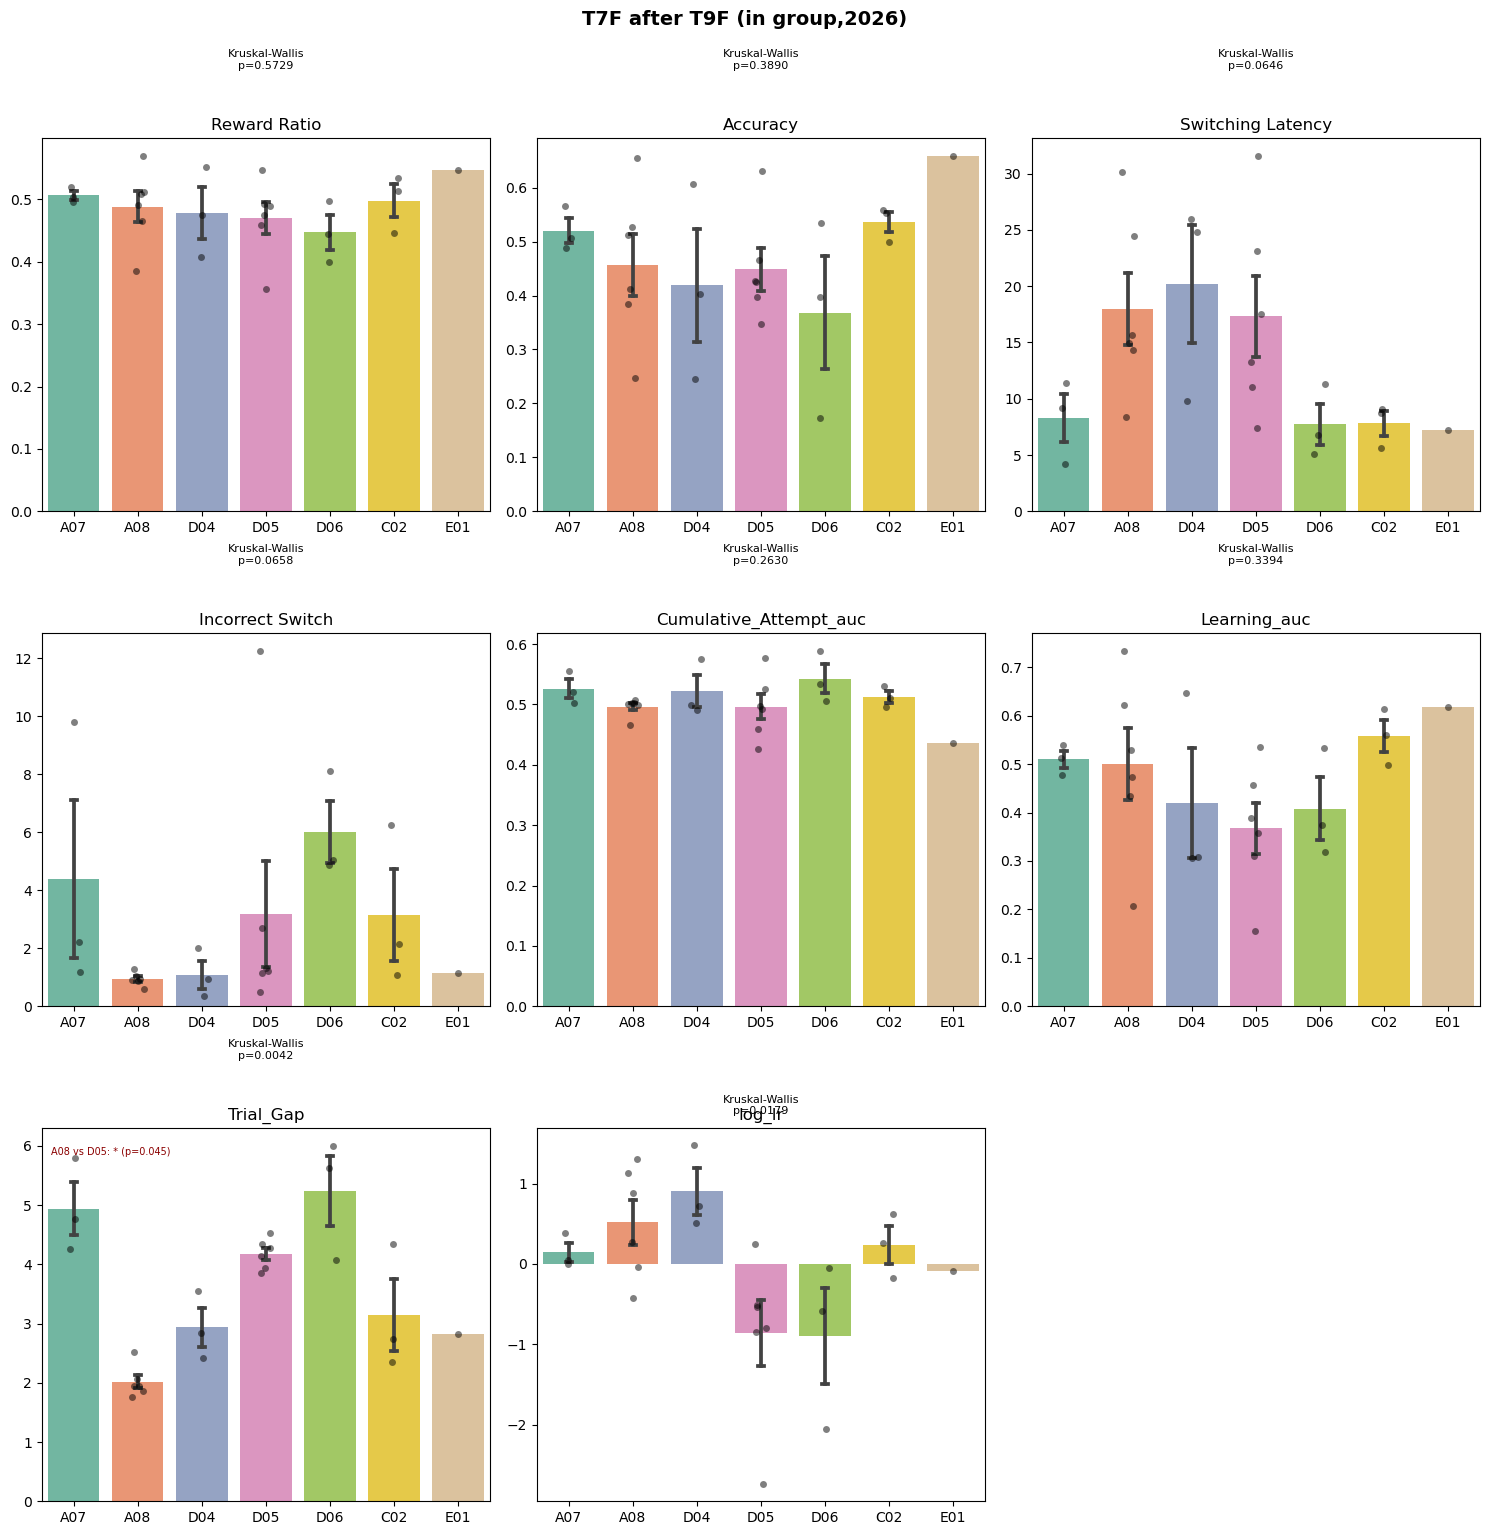

In [6]:
# ====================================================
# Multiple groups comparison (same mice, repeated measures)
# ====================================================
group_1 = analyzer.filter_data(mouse_id=['A07'], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_2 = analyzer.filter_data(mouse_id=['A08',], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_3 = analyzer.filter_data(mouse_id=['D04',], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_4 = analyzer.filter_data(mouse_id=['D05'], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_5 = analyzer.filter_data(mouse_id=['D06'], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_6 = analyzer.filter_data(mouse_id=['C02'], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_7 = analyzer.filter_data(mouse_id=['E01'], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")


group_dict = {
    "A07": group_1,
    "A08": group_2,
    "D04": group_3,
    "D05": group_4,
    "D06": group_5,
    "C02": group_6,
    "E01": group_7,
}

metrics_to_analyze = [
    'Reward Ratio', 'Accuracy', 'Switching Latency', 
    'Incorrect Switch', 'Cumulative_Attempt_auc', 
    'Learning_auc', 'Trial_Gap', 'log_lr'
]

analyzer.compare_multiple_groups(
    group_dict=group_dict,
    metrics=metrics_to_analyze,
    design="independent",  
    title="T7F after T9F (in group,2026)",
    show_ns=False

)


#####   两两分析：
检验差值正态性 → 符合则用 配对 T 检验 (Paired t-test) 
→ 不符合则用 Wilcoxon 符号秩检验。

In [ ]:
# ====================================================
# 两两比较分析（支持 paired 测试）
# ====================================================
group_1 = analyzer.filter_data(mouse_id=['G01', 'G02', 'G03','G04'],stage="", treatment="T9F", start_date="", label_name="T9F with P7F")

group_2_C02= analyzer.filter_data(mouse_id=['C02'],stage="", treatment="T7F", start_date="20251208",end_date='20251212', label_name="T7F with P7F")
group_2_C03= analyzer.filter_data(mouse_id=['C03'],stage="", treatment="T7F", start_date="",end_date='', label_name="T7F with P7F")
group_2_D04= analyzer.filter_data(mouse_id=['D04'],stage="", treatment="T7F", start_date="",end_date='20251128', label_name="T7F with P7F")
group_2_D06= analyzer.filter_data(mouse_id=['D06'],stage="", treatment="T7F", start_date="",end_date='20251128', label_name="T7F with P7F")
group_2 = pd.concat([group_2_C02,group_2_C03,group_2_D04,group_2_D06], ignore_index=True)

metrics_to_analyze = [
    'Reward Ratio', 'Accuracy', 'Switching Latency', 
    'Incorrect Switch', 'Cumulative_Attempt_auc', 
    'Learning_auc', 'Trial_Gap', 'log_lr'
]
analyzer.compare_and_plot(group_1, group_2, metrics=metrics_to_analyze, title="P7F effect on T9F or T7F", design="independent")
#同一只鼠连续做用repeated，不同鼠用independent


#####   相同任务前期 VS 后期

自动计算每只老鼠在“前几天”的所有数据均值、“后几天”的所有数据均值。
3.	利用这两个均值矩阵，验证差值的正态性，再执行配对T检验或Wilcoxon检验，给出最严谨的 P 值。
4.	画图时，仍然会在柱状图上散点展示所有的原始试验轮次。

Data for Accuracy 不是正态分布. Using Wilcoxon test instead of paired t-test.


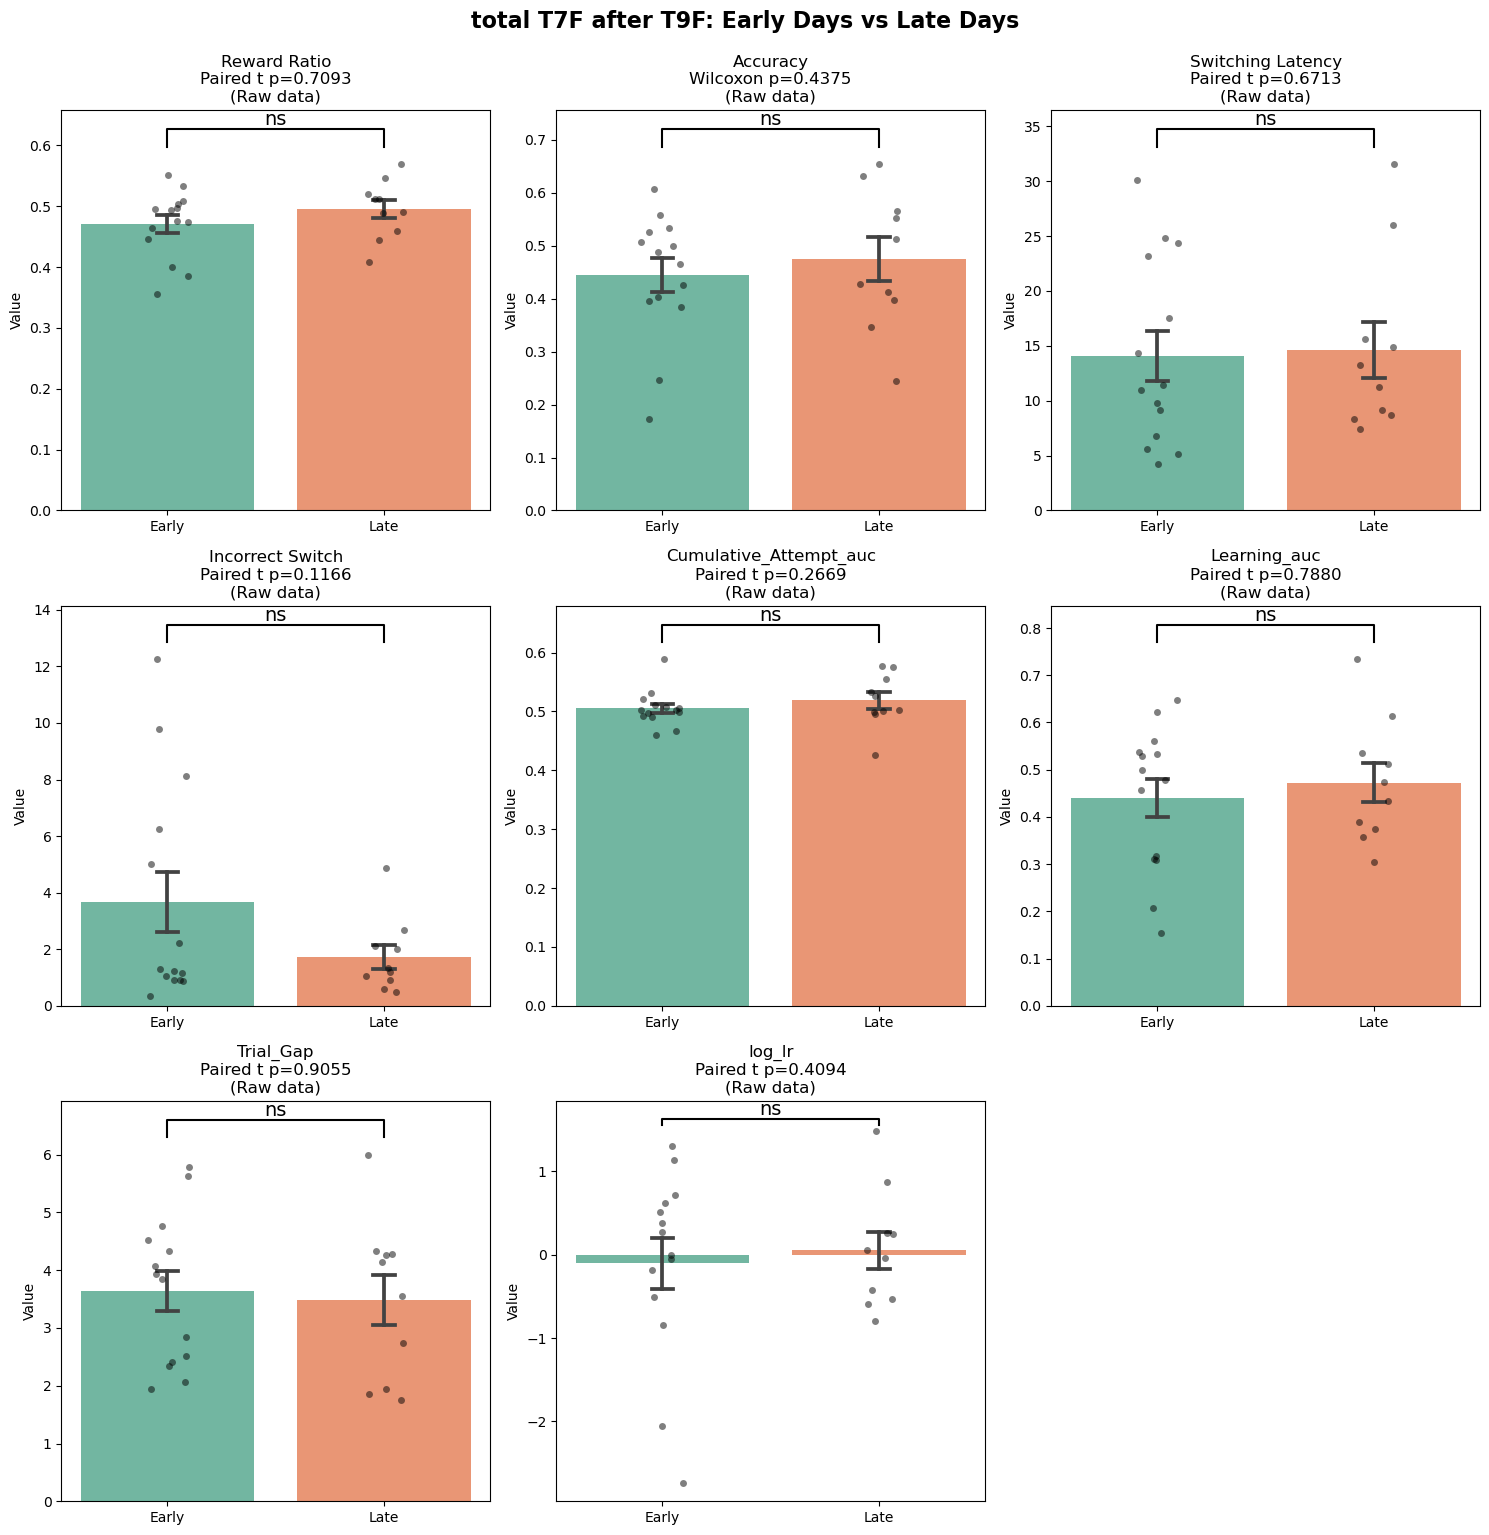

In [7]:
group_1 = analyzer.filter_data(mouse_id=['A07'], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_2 = analyzer.filter_data(mouse_id=['A08',], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_3 = analyzer.filter_data(mouse_id=['D04',], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_4 = analyzer.filter_data(mouse_id=['D05'], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_5 = analyzer.filter_data(mouse_id=['D06'], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_6 = analyzer.filter_data(mouse_id=['C02'], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")
group_7 = analyzer.filter_data(mouse_id=['E01'], stage="", treatment="T7F", start_date="20260101", label_name="T7F with P9F")


target_data = pd.concat([group_1,group_2,group_3,group_4,group_5,group_6,group_7], ignore_index=True)

metrics_to_analyze = [
    'Reward Ratio', 'Accuracy', 'Switching Latency', 
    'Incorrect Switch', 'Cumulative_Attempt_auc', 
    'Learning_auc', 'Trial_Gap', 'log_lr'
]

analyzer.split_and_compare_by_date(
    df=target_data, 
    metrics=metrics_to_analyze, 
    title="total T7F after T9F: Early Days vs Late Days"
)

可视化日志

In [ ]:
# analyzer = BehaviorDataAnalyzer('beh_total_rename.xlsx')
# # 筛选阶段4的T7F数据
# target_data = analyzer.filter_data(stage="Stage4", treatment="T7F")
# # 执行分析：会自动【打印原始表】+【展示对比图】
# analyzer.split_and_compare_by_date(target_data, metrics=['Accuracy', 'Reward Ratio'])
# 初始化你的分析器
analyzer = BehaviorDataAnalyzer('/home/jyy/Documents/Beh_Ana/beh_total_rename_r.xlsx')

# 直接调用全景图打印功能
analyzer.plot_training_log()

非可视化日志日志

In [20]:
# analyzer = BehaviorDataAnalyzer('/home/jyy/Documents/Beh_Ana/beh_total_rename_r.xlsx')

# 打印你新要求的表格格式
analyzer.print_pipeline_table()



==================== COMPACT TRAINING PIPELINE TABLE ====================
A04 P9Fx3 T9Fx15 
A05 P9Fx4 T9Fx6 
A06 P9Fx3 T9Fx6 
A07 P9Fx3 T9Fx6 (间隔 12 个月) T9Fx4 T7Fx1 T9Fx1 T7Fx2 m50p9Fx1 m50p7Fx5 m25p7Fx1 
A08 P9Fx5 T9Fx6 T7Fx3 m50p7Fx1 T7Fx3 m50p7Fx2 m25p7Fx2 
B02 00x1 T9Fx2 F9Fx3 E7Fx1 T7Fx6 T9Fx1 T7Fx3 T9Fx1 T5Fx2 F7Fx3 D7Fx3 m0p7Fx1 m0p9Fx1 m25p9Fx1 m12p9Fx1 m50p9Fx2 m50p7Fx1 m25p9Fx3 m12p7Fx1 m12p9Fx1 Ac7Fx4 
B04 T9Fx3 F9Fx2 T7Fx9 T9Fx1 T5Fx2 F7Fx4 D7Fx3 m0p7Fx1 m25p9Fx1 m12p9Fx1 m50p9Fx3 m25p9Fx3 m12p9Fx2 Ac7Fx4 
B05 00x1 P7Fx1 T7Fx6 T9Fx4 T7Fx4 T5Fx3 F7Fx4 D7Fx1 m0p7Fx1 m0p9Fx1 m25p9Fx1 m12p9Fx1 m50p9Fx3 m25p9Fx3 m12p9Fx2 Ac7Fx4 
B06 P9Fx2 T9Fx5 T7Fx4 T5Fx3 F7Fx4 (间隔 1 个月) m25p9Fx1 m12p9Fx1 m50p9Fx3 m25p9Fx3 m12p9Fx2 Ac7Fx4 
B07 P9Fx2 T9Fx5 T7Fx4 T5Fx3 F7Fx4 (间隔 1 个月) m0p9Fx1 m25p9Fx1 m12p9Fx1 m50p9Fx3 m25p9Fx3 m12p9Fx2 Ac7Fx4 
C01 T9Fx1 P9Fx1 T9Fx13 
C02 P7Fx2 T7Fx5 T9Fx4 T7Fx5 (间隔 2 个月) T9Fx5 T7Fx3 m50p7Fx1 m50p9Fx1 m50p7Fx4 m25p7Fx2 
C03 P7Fx2 T7Fx5 T9Fx4 
C04 P9Fx5 T9Fx4 
D0


分析的特定序列

In [ ]:
analyzer = BehaviorDataAnalyzer('/home/jyy/Documents/Beh_Ana/beh_total_rename_r.xlsx')

my_seq = ["P9F", "T9F", "T7F","T9F"]

target_metrics = ['Reward Ratio', 'Accuracy', 'Switching Latency', 
    'Incorrect Switch', 'Cumulative_Attempt_auc', 
    'Learning_auc', 'Trial_Gap', 'log_lr']

analyzer.filter_pipeline_sequence(sequence=my_seq, metrics=target_metrics,strict=False)


In [ ]:
# analyzer = BehaviorDataAnalyzer('/home/jyy/Documents/Beh_Ana/beh_total_rename_r.xlsx')
analyzer.print_training_pipeline()

# 场景 2：只查看某一只特定老鼠（如 A04）的流程
# analyzer.print_training_pipeline(mouse_id="A04")

In [ ]:
# analyzer.print_training_pipeline2()

####    回归分析

[Accuracy] Robust Regression (Huber) used


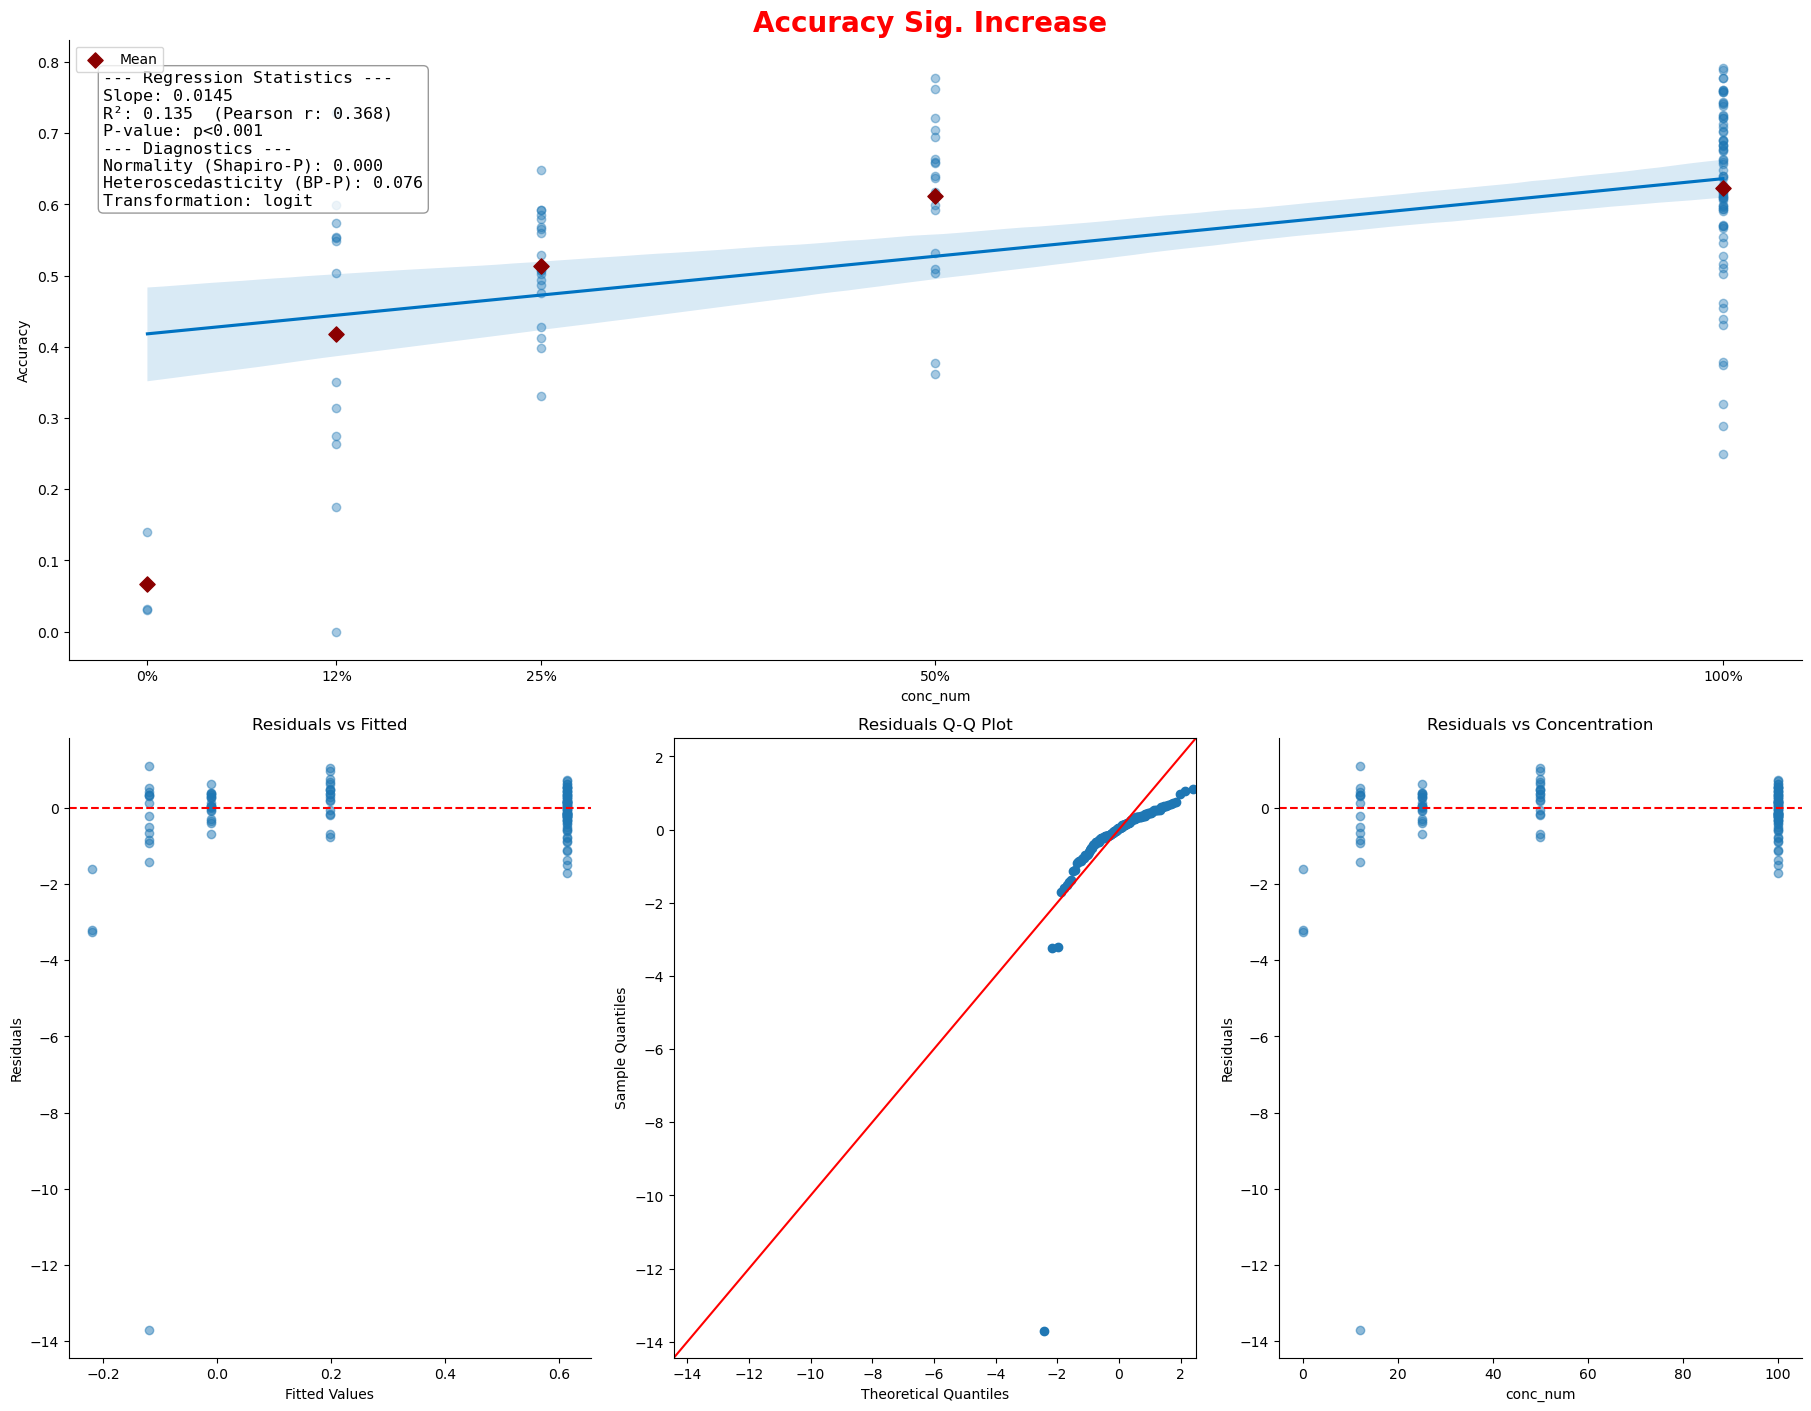

[Accuracy] Design: Repeated measures design: use paired t-test / Wilcoxon signed-rank


In [32]:
conc_map = {
    'T7F': 100,
    'T9F': 100,
    'm50p7F': 50,
    'm50p9F': 50,
    'm25p9F': 25,
    'm25p7F': 25,
    'm0p7F': 0,
    'm0p9F': 0,
    'm12p9F': 12,
    'm12p7F': 12,
}

analyzer.df['conc_num'] = analyzer.df['Treatment'].map(conc_map)

group_1 = analyzer.filter_data(
    treatment=['m50p9F','m25p9F','m12p9F','m0p9F'] # 也可以不填，默认全选
)
group_2 = analyzer.filter_data(mouse_id=['A04', 'A05', 'A06','A08','B06','B07','C04','D01','D03', 'D05','E01'], stage="", treatment="T9F", start_date="", label_name="T9F with P9F")
group = pd.concat([group_1,group_2], ignore_index=True)

my_metrics = [
    'Accuracy'
]

df_results_repeated = analyzer.analyze_regression_pipeline(
    df=group,
    x_col='conc_num',
    metrics=my_metrics,
    design='repeated',
    transformation='logit',#square/log/sqrt/logit/None

    remove_outliers=False,
    outlier_method="both",

    robust=True,
    save_outliers=True,
    # title_suffix="(logit Transform)"
)

In [21]:
# 1. 先检查 Treatment 列有哪些唯一值
print("所有 Treatment 值：")
print(analyzer.df['Treatment'].unique())

# 2. 检查浓度映射是否生效
print("\n浓度映射结果检查：")
print(analyzer.df[['Treatment', 'conc_num']].drop_duplicates())

# 3. 检查筛选结果
print("\ngroup_1 包含的 Treatment：")
print(group_1['Treatment'].unique())
print(f"group_1 行数: {len(group_1)}")

# 4. 检查 group 中每个 treatment 的数量
print("\n各 Treatment 数据点数量：")
print(analyzer.df['Treatment'].value_counts())


所有 Treatment 值：
['P9F' 'T9F' '00' 'F9F' 'E7F' 'T7F' 'P7F' 'T5F' 'F7F' 'D7F' 'm0p7F'
 'm0p9F' 'm25p9F' 'm12p9F' 'T8F' 'F8F' 'm50p9F' 'm50p7F' 'm12p7F' 'Am7W'
 'T7W' 'Ac7F' 'F7W' 'T6F' 'm25p7F']

浓度映射结果检查：
    Treatment  conc_num
0         P9F       NaN
12        T9F     100.0
21         00       NaN
91        F9F       NaN
96        E7F       NaN
97        T7F     100.0
102       P7F       NaN
154       T5F       NaN
169       F7F       NaN
188       D7F       NaN
205     m0p7F       0.0
212     m0p9F       0.0
222    m25p9F      25.0
235    m12p9F      12.0
240       T8F       NaN
257       F8F       NaN
274    m50p9F      50.0
291    m50p7F      50.0
319    m12p7F      12.0
333      Am7W       NaN
349       T7W       NaN
393      Ac7F       NaN
394       F7W       NaN
410       T6F       NaN
465    m25p7F      25.0

group_1 包含的 Treatment：
['m0p9F' 'm25p9F' 'm12p9F' 'm50p9F']
group_1 行数: 55

各 Treatment 数据点数量：
Treatment
T9F       142
T7F       110
P9F        42
m50p7F     26
F7F       